# Project Overview

Goal:
Identify major drivers of customer churn at a telecom company and recommend retention strategies.

Key Findings:
- Month-to-month contracts have highest churn
- New customers are high-risk
- Tenure strongly negatively correlates with churn

# Preprocessing

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure
from matplotlib.ticker import FuncFormatter

### Read in dataset

In [2]:
df = pd.read_csv("/Users/rykerboeh/projects/Data Analytics/Portfolio Projects/telco_churn_python/telco_churn_data.csv")

# Explore data

### How many rows and columns are in the dataset?

In [3]:
df.shape

(7043, 50)

### What data types are present?

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

### Data Overview

In [5]:
pd.set_option('display.max_columns', None)
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [6]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


# Clean/standardize columns

### Are there missing values?

In [7]:
# Count how many records per column contain NULL values
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

### Are there duplicate records?

In [8]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

# Explore customer churn:

### Churn counts

In [9]:
# Customer counts by customer status
df['Customer Status'].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

### What percentage of customers churn?

In [39]:
# Calculate gross and net customer churn rates
churn_counts = df['Customer Status'].value_counts()

churned = churn_counts['Churned']
stayed = churn_counts['Stayed']
joined = churn_counts['Joined']

gross_churn_percentage = (churned / (churned + stayed)) * 100
net_churn_percentage = ((churned - joined) / (churned + stayed) * 100)

print(f"Gross Customer Churn Percentage: {gross_churn_percentage:.2f}%")
print(f"Net Customer Churn Percentage: {net_churn_percentage:.2f}%")

Gross Customer Churn Percentage: 28.37%
Net Customer Churn Percentage: 21.48%


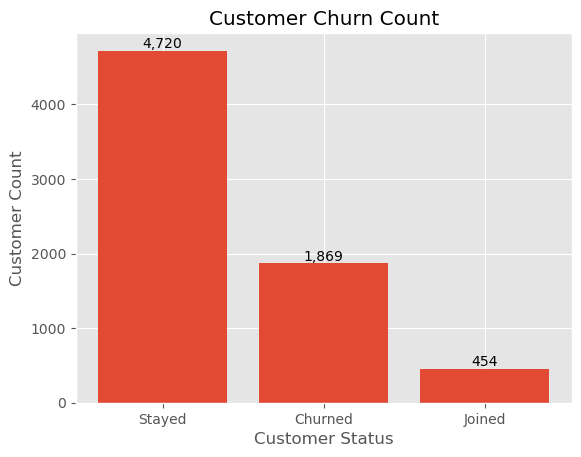

In [11]:
# Create bar chart visualizing customer count by customer status
churn_bar = plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title('Customer Churn Count')
plt.xlabel('Customer Status')
plt.ylabel('Customer Count')

# Add value labels on bars
for bar in churn_bar:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,}',
        ha='center',
        va='bottom'
    )

plt.show()

### Churn implications on revenue

In [38]:
# Calculate total revenues by customer status and revenue churn rate
revenue_by_status = (
    df.groupby('Customer Status')['Total Revenue']
    .sum()
)

churned = revenue_by_status['Churned']
stayed = revenue_by_status['Stayed']

revenue_churn_rate = churned / (stayed + churned)

print(revenue_by_status)
print(f"Revenue churn rate: {revenue_churn_rate:.2%}")

Customer Status
Churned     3684459.82
Joined        54279.75
Stayed     17632392.12
Name: Total Revenue, dtype: float64
Revenue churn rate: 17.28%


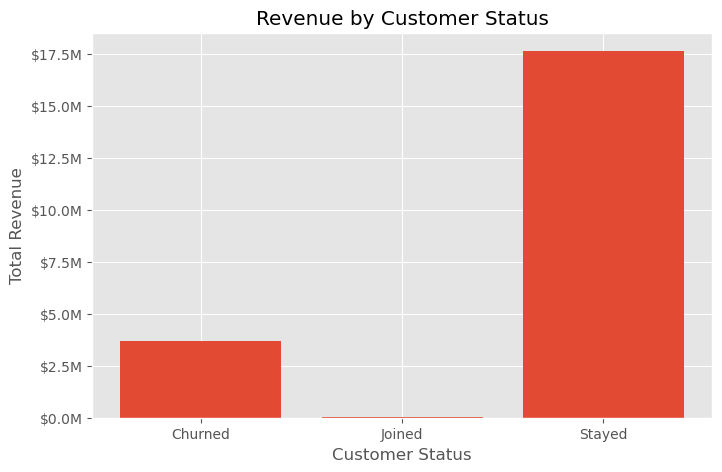

In [13]:
# Create bar chart visualizing revenue by customer status
plt.figure(figsize=(8,5))

bars = plt.bar(
    revenue_by_status.index,
    revenue_by_status.values
)

plt.title('Revenue by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Total Revenue')

# Y-axis in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

plt.show()

# Contract/subscription analysis:

### Which contract types churn most?

In [45]:
# Calculate churn by contract type
contract_status_counts = pd.crosstab(
    df['Contract'],
    df['Customer Status'],
    #normalize = True
).round(2)

print(contract_status_counts)

Customer Status  Churned  Joined  Stayed
Contract                                
Month-to-Month      1655     408    1547
One Year             166      24    1360
Two Year              48      22    1813


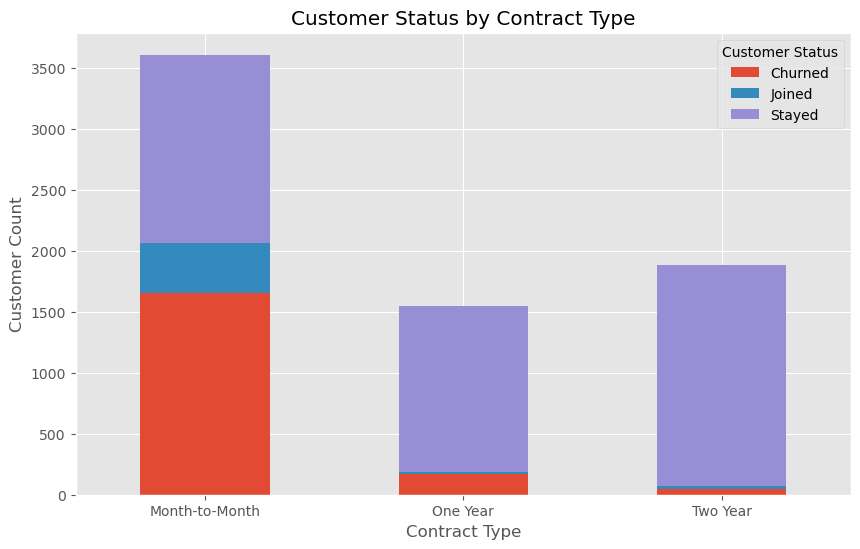

In [46]:
# Create stacked bar chart visualizing customer status by contract type
contract_status_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Customer Status by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')

plt.xticks(rotation=0)

plt.show()

### Does offer affect contract type?

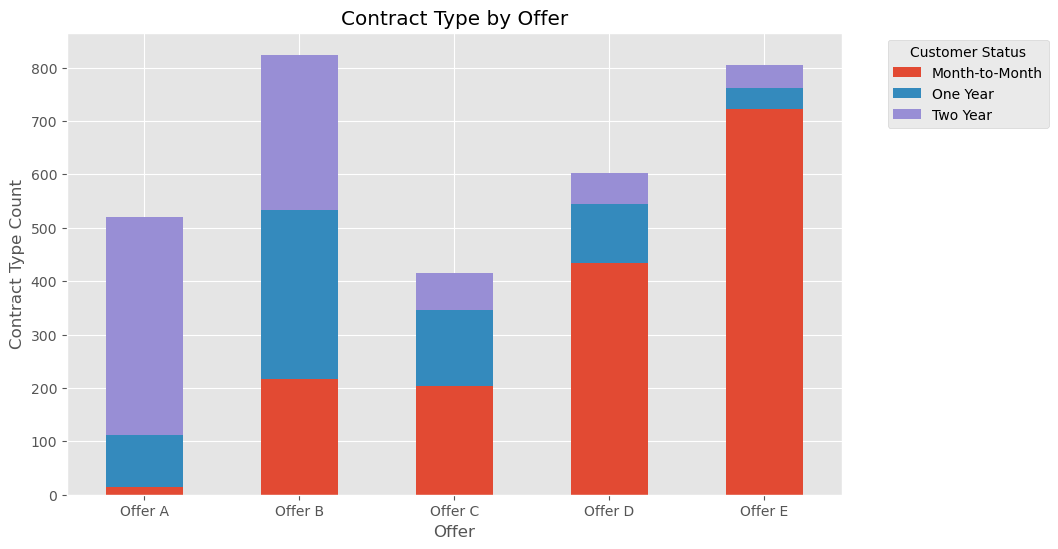

In [16]:
# Create stacked bar chart visualizing contract type by offer
offer_contract_count = pd.crosstab(
    df['Offer'],
    df['Contract']
)

offer_contract_count.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Contract Type by Offer')
plt.xlabel('Offer')
plt.ylabel('Contract Type Count')

plt.xticks(rotation=0)

plt.legend(title='Customer Status', bbox_to_anchor=(1.05, 1))

plt.show()

### Does internet service type affect churn?

In [17]:
# Calculate churn rate by internet type
internet_type_status_counts = pd.crosstab(
    df['Internet Type'],
    df['Customer Status'],
    normalize = True
).round(2)

print(internet_type_status_counts)

Customer Status  Churned  Joined  Stayed
Internet Type                           
Cable               0.04    0.01    0.10
DSL                 0.06    0.02    0.22
Fiber Optic         0.22    0.02    0.31


### Which add-on services reduce churn?

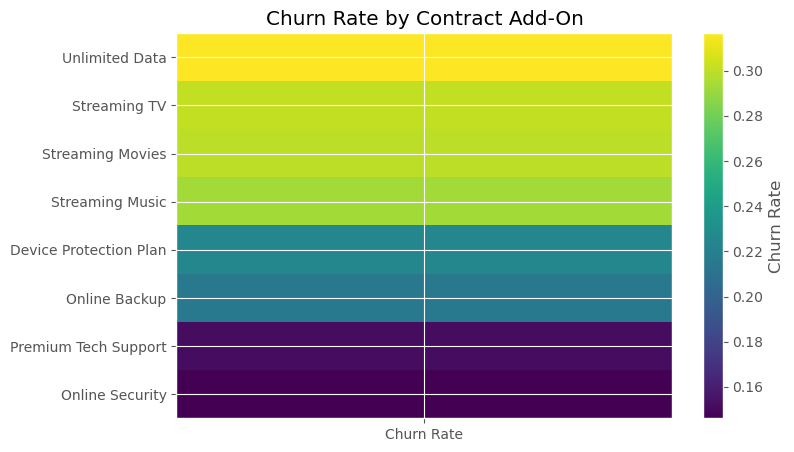

In [18]:
# Create heatmap visualizing contract add-on correlation to churn

df['is_churned'] = (
    df['Customer Status'] == 'Churned'
).astype(int)

addon_cols = [
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data'
]

results = {}

for col in addon_cols:
    churn_rates = df.groupby(col)['is_churned'].mean()

    # Usually interested in "Yes"
    if 'Yes' in churn_rates.index:
        results[col] = churn_rates['Yes']

heatmap_df = pd.DataFrame.from_dict(
    results,
    orient='index',
    columns=['Churn Rate']
)

heatmap_df = heatmap_df.sort_values(
    by='Churn Rate',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.imshow(
    heatmap_df,
    aspect='auto'
)

plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index
)

plt.xticks([0], ['Churn Rate'])

plt.colorbar(label='Churn Rate')

plt.title('Churn Rate by Contract Add-On')

plt.show()

# Correlation analysis:

### Which numerical variables correlate with churn?

In [19]:
# Calculate coefficients for numerical variables' correlation to churn
corr_series = df.corrwith(df['is_churned'], numeric_only=True)

print(corr_series.sort_values(ascending=False))

is_churned                           1.000000
Churn Score                          0.660772
Monthly Charge                       0.193356
Age                                  0.115760
Population                           0.051649
Avg Monthly GB Download              0.048868
Longitude                            0.024052
Avg Monthly Long Distance Charges    0.008120
Total Extra Data Charges             0.007139
Zip Code                            -0.016289
Total Refunds                       -0.033709
Latitude                            -0.041546
CLTV                                -0.127463
Total Charges                       -0.198546
Number of Dependents                -0.218780
Total Revenue                       -0.223003
Total Long Distance Charges         -0.223756
Number of Referrals                 -0.286540
Tenure in Months                    -0.352861
Satisfaction Score                  -0.754649
dtype: float64


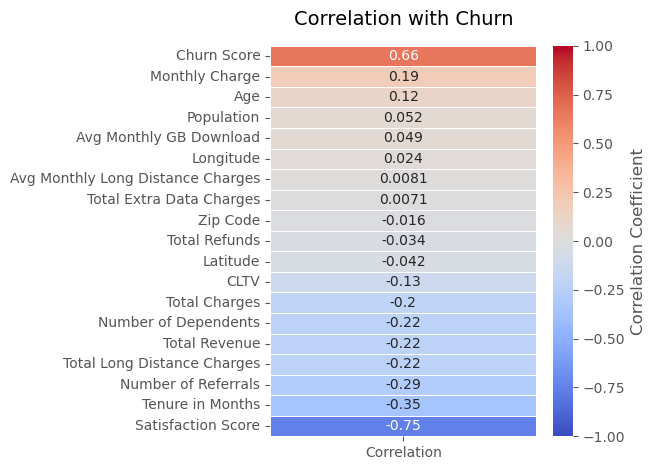

In [20]:
# Create heatmap visualizing numerical variable correlation to churn

# Create data frame based on correlations
corr_df = corr_series.to_frame(name="Correlation").sort_values(
    by="Correlation", ascending=False
)

# Remove the churn self-correlation
corr_df = corr_df.drop(index="is_churned")

# Generate the single-column heatmap
sns.heatmap(
    corr_df,
    annot=True,  # Display the numeric values inside the cells
    cmap="coolwarm",  # Red for positive, blue for negative correlations
    vmin=-1,  # Set the minimum anchor value for the color scale
    vmax=1,  # Set the maximum anchor value for the color scale
    linewidths=0.5,  # Add fine lines between cells for scannability
    cbar_kws={"label": "Correlation Coefficient"},
)

# Final layout adjustments
plt.title("Correlation with Churn", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Are monthly charges correlated with tenure?

In [21]:
# Calculate correlation coefficient for monthly and total charges to customer tenure
monthly_charge_corr = df['Monthly Charge'].corr(df['Tenure in Months']).round(2)
total_charge_corr = df['Total Charges'].corr(df['Tenure in Months']).round(2)

print(f"Monthly charge correlation to tenure: {monthly_charge_corr}")
print(f"Total charge correlation to tenure: {total_charge_corr}")

Monthly charge correlation to tenure: 0.25
Total charge correlation to tenure: 0.83


# Customer segments:

### Tenure Groups

In [22]:
# Create tenure groups and analyze churn rates by tenure group
df['Tenure Group'] = pd.cut(
    df['Tenure in Months'],
    bins=[0,12,24,48,72],
    labels=[
        'New',
        'Developing',
        'Established',
        'Loyal'
    ]
)

tenure_churn = df.groupby('Tenure Group')['Customer Status'].value_counts(normalize=True).unstack().round(2)
print(tenure_churn)

Customer Status  Churned  Joined  Stayed
Tenure Group                            
New                 0.47    0.21    0.32
Developing          0.29    0.00    0.71
Established         0.20    0.00    0.80
Loyal               0.10    0.00    0.90


/var/folders/n8/ptplg2kd2vz25c8k2wfp8bmc0000gn/T/ipykernel_41784/2221595377.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('Tenure Group')['Customer Status'].value_counts(normalize=True).unstack().round(2)


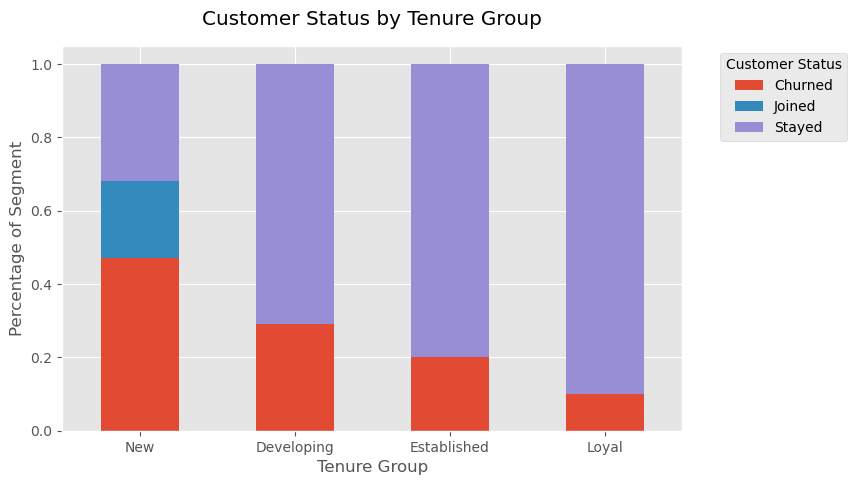

In [23]:
# Create stacked bar chart visualizing churn by tenure group
tenure_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

# Titles and labels
plt.title('Customer Status by Tenure Group', pad = 15)
plt.xlabel('Tenure Group')
plt.ylabel('Percentage of Segment')

# Rotate x labels for readability
plt.xticks(rotation=0)

# Move legend outside chart
plt.legend(title='Customer Status', bbox_to_anchor=(1.05, 1))

plt.show()

### Spending Tiers

In [24]:
# Create spending tiers and analyze churn rates by spending tiers
df['Spending Tier'] = pd.qcut(
    df['Total Charges'],
    q=3,
    labels=['Low','Medium','High']
)

spending_churn = df.groupby('Spending Tier')['Customer Status'].value_counts(normalize=True).unstack().round(2)
print(spending_churn)

Customer Status  Churned  Joined  Stayed
Spending Tier                           
Low                 0.39    0.19    0.41
Medium              0.24    0.00    0.76
High                0.17    0.00    0.83


/var/folders/n8/ptplg2kd2vz25c8k2wfp8bmc0000gn/T/ipykernel_41784/3790298756.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spending_churn = df.groupby('Spending Tier')['Customer Status'].value_counts(normalize=True).unstack().round(2)


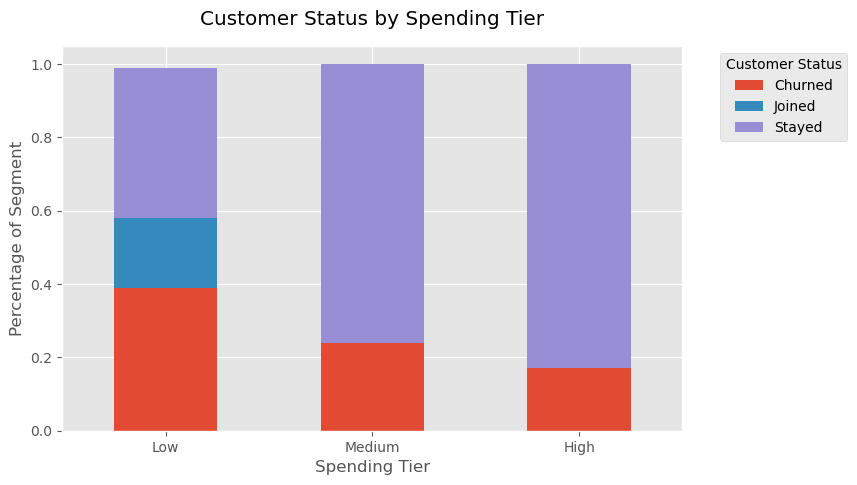

In [25]:
# Create stacked bar chart visualizing churn by spending tier
spending_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

# Titles and labels
plt.title('Customer Status by Spending Tier', pad = 15)
plt.xlabel('Spending Tier')
plt.ylabel('Percentage of Segment')

# Rotate x labels for readability
plt.xticks(rotation=0)

# Move legend outside chart
plt.legend(title='Customer Status', bbox_to_anchor=(1.05, 1))

plt.show()

### Value Segments

In [26]:
# Create value segments based on tenure group and spending tier and analyze churn rates by value segments
conditions = [

    # High-value loyal customers
    (
        (df['Tenure Group'] == 'Loyal') &
        (df['Spending Tier'] == 'High')
    ),

    # High-paying but risky customers
    (
        (df['Tenure Group'] == 'New') &
        (df['Spending Tier'] == 'High')
    ),

    # Low-value risky customers
    (
        (df['Tenure Group'] == 'New') &
        (df['Spending Tier'] == 'Low')
    ),

    # Stable middle customers
    (
        (df['Tenure Group'] == 'Established') &
        (df['Spending Tier'] == 'Medium')
    )
]

labels = [
    'High Value Loyal',
    'Premium Risk',
    'Low Value Risk',
    'Stable Mid-Tier'
]

df['Value Segment'] = np.select(
    conditions,
    labels,
    default='Other'
)
value_segment_churn = (
    df.groupby('Value Segment')['Customer Status']
      .value_counts(normalize=True)
      .unstack()
      .round(2)
)

print(value_segment_churn)

Customer Status   Churned  Joined  Stayed
Value Segment                            
High Value Loyal     0.12     NaN    0.88
Low Value Risk       0.46    0.23    0.30
Other                0.25     NaN    0.75
Stable Mid-Tier      0.16     NaN    0.84


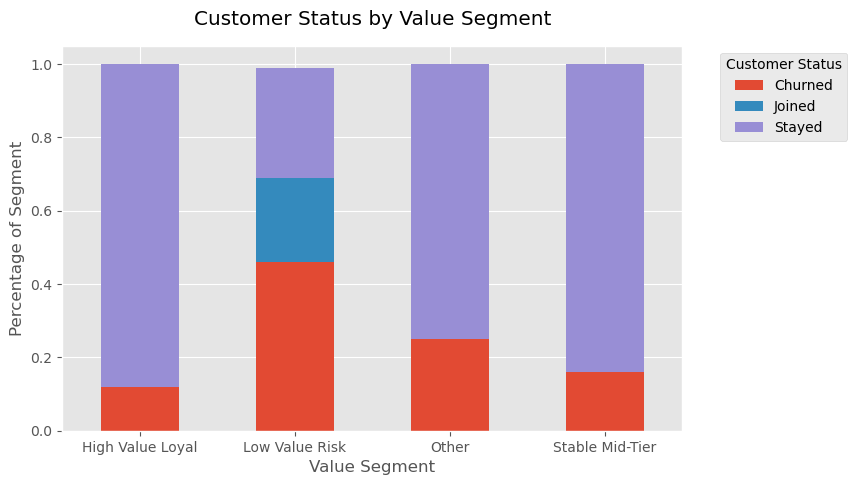

In [27]:
# Create stacked bar chart visualizing churn by value segment
value_segment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

# Titles and labels
plt.title('Customer Status by Value Segment', pad = 15)
plt.xlabel('Value Segment')
plt.ylabel('Percentage of Segment')

# Rotate x labels for readability
plt.xticks(rotation=0)

# Move legend outside chart
plt.legend(title='Customer Status', bbox_to_anchor=(1.05, 1))

plt.show()

In [35]:
# Calculate total revenue by value segment
revenue_by_segment = (
    df.groupby('Value Segment')['Total Revenue']
      .sum()
      .sort_values(ascending=False)
)

print(revenue_by_segment)

Value Segment
High Value Loyal    12319483.13
Other                6389554.44
Stable Mid-Tier      2084511.04
Low Value Risk        577583.08
Name: Total Revenue, dtype: float64


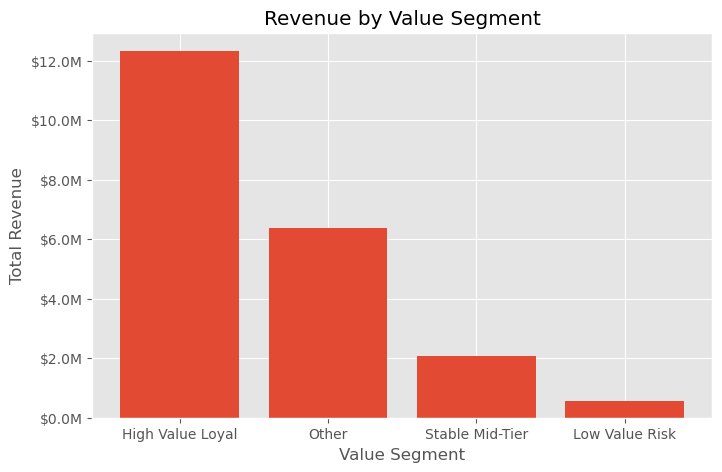

In [36]:
# Create bar chart visualizing revenue by value segment
plt.figure(figsize=(8,5))

bars = plt.bar(
    revenue_by_segment.index,
    revenue_by_segment.values
)

plt.title('Revenue by Value Segment')
plt.xlabel('Value Segment')
plt.ylabel('Total Revenue')

# Y-axis in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

plt.show()

# Conclusion and Retention Strategy

## Summary of Analysis
- Net Customer Churn Percentage: 21.48%
- Revenue churn rate: 17.28%
- 89% of churned customers held month-to-month contracts
- Contracts with online security and premium tech support add-ons exhibit lower churn rates
- Customer tenure has significant negative correlation to churn
- Churn rate is highest amongst low spending customer segment
- "High-value loyal" customer segment is the most valuable and stable customer segment by far
- New customers with month-to-month contracts are the customer segment with the highest risk to churn

## Retention Strategy
- The company should prioritize retention of "high-value loyal" customer segment and fitting new customers with longer contracts rather than month-to-month contracts. Offers A and B may be leveraged to priorize securing long-term contracts, reducing customer churn, and bolstering the high-value loyal customer segment. Additionally, increasing contracts with online security and premium tech support add-ons may support customer retention.